#**Worksheet - 5**

**Name: Ankit Khatiwada**<br>
**UniID: 2361013**

___________________________________________________________________________________________

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_path = '/content/drive/MyDrive/Artificial Intelligence 6CS012/Week 5/FruitinAmazon/train'
test_path = '/content/drive/MyDrive/Artificial Intelligence 6CS012/Week 5/FruitinAmazon/test'

In [5]:
category_dirs = [directory for directory in os.listdir(train_path)
                 if os.path.isdir(os.path.join(train_path, directory))]
category_dirs.sort()  # Sorting alphabetically
print("The categories are:", category_dirs)

The categories are: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [6]:
num_categories = len(category_dirs)
num_columns = (num_categories + 1) // 2


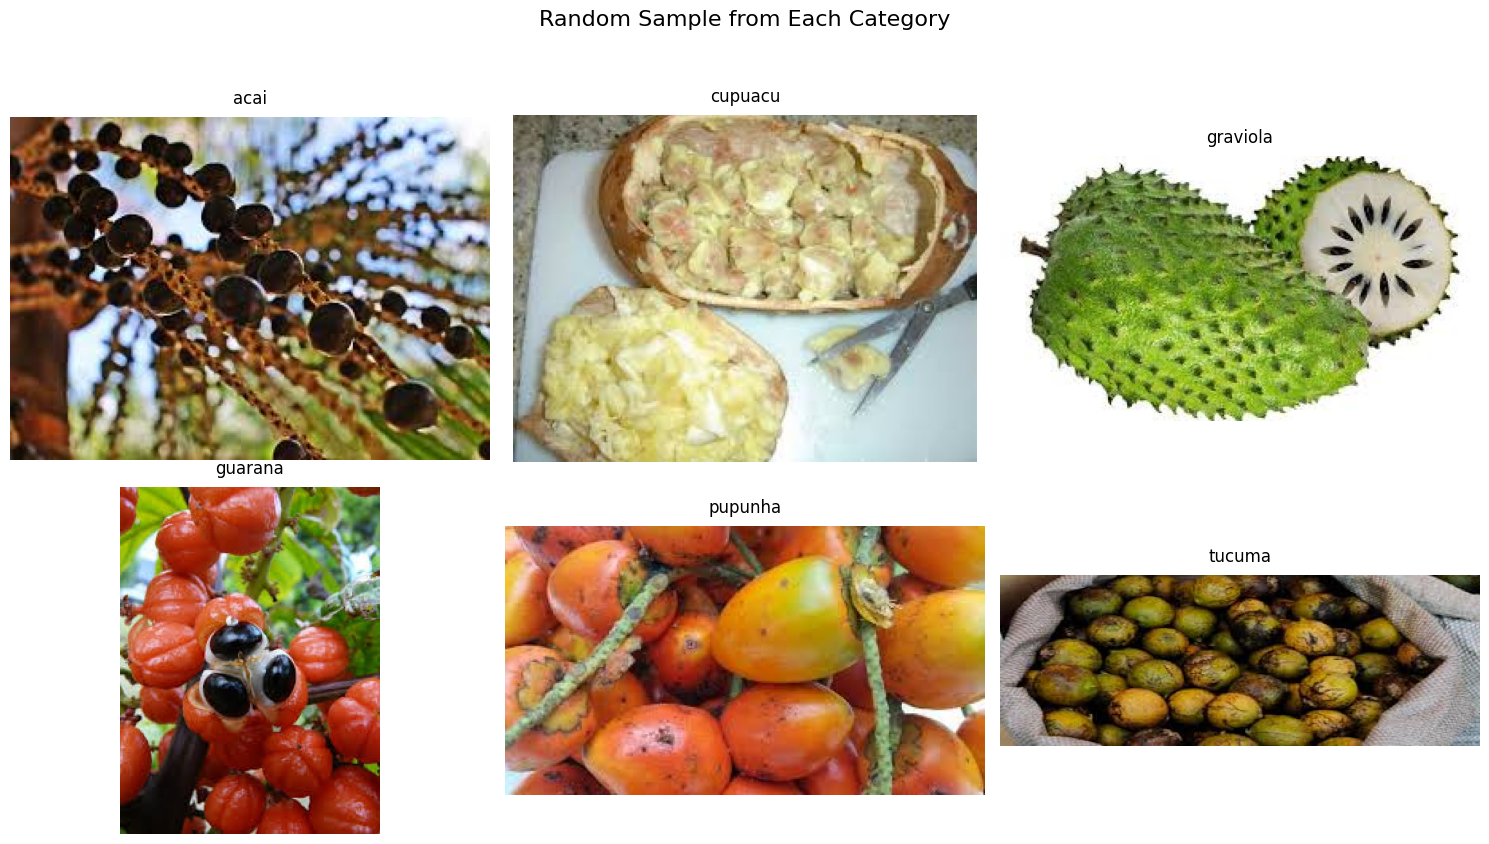

In [7]:
plt.figure(figsize=(15, 8))
plt.suptitle("Random Sample from Each Category", fontsize=16, y=1.05)

for i, category_name in enumerate(category_dirs):
    # Get all images in the category directory
    category_path = os.path.join(train_path, category_name)
    image_files = [file for file in os.listdir(category_path)
                   if os.path.isfile(os.path.join(category_path, file))]

    # Select a random image
    if image_files:  # Only proceed if there are images in the directory
        random_image = random.choice(image_files)
        img_path = os.path.join(category_path, random_image)

        # Open and display the image
        try:
            img = Image.open(img_path)

            # Create subplot
            plt.subplot(2, num_columns, i + 1)
            plt.imshow(img)
            plt.title(category_name, pad=10)
            plt.axis('off')

        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
    else:
        print(f"No images found in category: {category_name}")

plt.tight_layout()
plt.show()


**What did you Observe?**

Acal, cupuacu, graviola, guarana, pupunha, and tucuma are the six fruit groups listed in the output from the Amazon.  The list offers a concise synopsis of the many fruit varieties included in the training folder of your dataset.

In [8]:
# CHECKING FOR CORRUPTED IMAGES

from PIL import Image, ImageFile
import os

ImageFile.LOAD_TRUNCATED_IMAGES = True  # Ensures truncated images don't crash the process

def check_and_remove_corrupted_images(dataset_directory):
    corrupted_image_paths = []

    for root, _, filenames in os.walk(dataset_directory):
        for filename in filenames:
            image_path = os.path.join(root, filename)

            if not filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                continue  # Skip non-image files

            try:
                # Verify the image integrity
                with Image.open(image_path) as img:
                    img.verify()

                # Load the image to further check if it's readable
                with Image.open(image_path) as img:
                    img.load()

            except (IOError, SyntaxError, Image.DecompressionBombError) as error:
                print(f"Removed corrupted image: {image_path} - Error: {str(error)}")
                corrupted_image_paths.append(image_path)
                os.remove(image_path)

    return corrupted_image_paths


corrupted_images = check_and_remove_corrupted_images(train_path)

if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


In [11]:
#LOADING AND PREPROCESSING THROUGH KERAS

import tensorflow as tf

# Define dataset path and parameters
dataset_directory = '/content/drive/MyDrive/Artificial Intelligence 6CS012/Week 5/FruitinAmazon/train'
image_height, image_width = 128, 128
batch_size = 32
validation_ratio = 0.2
random_seed = 123

# Load training dataset
train_dataset_unmapped = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_directory,
    labels='inferred',
    label_mode='int',
    image_size=(image_height, image_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_ratio,
    subset='training',
    seed=random_seed
)

# Load validation dataset
validation_dataset_unmapped = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_directory,
    labels='inferred',
    label_mode='int',
    image_size=(image_height, image_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,  # No need to shuffle validation data
    validation_split=validation_ratio,
    subset='validation',
    seed=random_seed
)

# Get class names
class_labels = train_dataset_unmapped.class_names
print("\nCategories identified in the dataset:", class_labels)

# Normalize images
normalize_layer = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset_unmapped.map(lambda x, y: (normalize_layer(x), y))
validation_dataset = validation_dataset_unmapped.map(lambda x, y: (normalize_layer(x), y))

# Inspect a batch
for image_batch, label_batch in train_dataset.take(1):
    print("\nDisplaying details of the first training batch:")
    print(f"- Number of images in batch: {image_batch.shape[0]}")
    print(f"- Image dimensions: {image_batch.shape[1]}x{image_batch.shape[2]} pixels")
    print(f"- Number of color channels: {image_batch.shape[3]}")
    print(f"- Number of labels in batch: {label_batch.shape[0]}")
    print("Pixel value range after normalization: {:.2f} to {:.2f}".format(
        tf.reduce_min(image_batch).numpy(),
        tf.reduce_max(image_batch).numpy()
    ))


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.

Categories identified in the dataset: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

Displaying details of the first training batch:
- Number of images in batch: 32
- Image dimensions: 128x128 pixels
- Number of color channels: 3
- Number of labels in batch: 32
Pixel value range after normalization: 0.00 to 1.00


In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_model(input_shape=(128, 128, 3), num_classes=6):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),  # Dropout for regularization
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Define model with dynamic input shape
cnn_model = build_cnn_model(input_shape=(image_height, image_width, 3), num_classes=len(class_labels))

# Compile the model
cnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Print model summary
cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       8,388,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,484,550 (32.37 MB)

 Trainable params: 8,484,102 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
# COMPILING THE MODEL
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(name='sparse_categorical_loss'),
    metrics=[
        'accuracy',
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_accuracy'),
        tf.keras.metrics.SparseCategoricalCrossentropy(name='categorical_xentropy')
    ]
)

# Verify compilation details
print("\n Model successfully compiled!")
print(f" Optimizer: {cnn_model.optimizer.get_config()['name']}")
print(f" Learning Rate: {cnn_model.optimizer.learning_rate.numpy()}")
print(f" Loss Function: {cnn_model.loss}")
print(f" Metrics Tracked: {[metric.name for metric in cnn_model.metrics]}")



 Model successfully compiled!
 Optimizer: adam
 Learning Rate: 0.0010000000474974513
 Loss Function: <LossFunctionWrapper(<function sparse_categorical_crossentropy at 0x7c92695e1080>, kwargs={'from_logits': False, 'ignore_class': None})>
 Metrics Tracked: ['loss', 'compile_metrics']


Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2141 - categorical_xentropy: 10.2913 - loss: 10.2913 - top2_accuracy: 0.3646
Epoch 1: val_accuracy improved from -inf to 0.00000, saving model to best_model.h5


3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2196 - categorical_xentropy: 11.0940 - loss: 11.0940 - top2_accuracy: 0.3672 - val_accuracy: 0.0000e+00 - val_categorical_xentropy: 2.4571 - val_loss: 2.4571 - val_top2_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6047 - categorical_xentropy: 6.1888 - loss: 6.1888 - top2_accuracy: 0.8501
Epoch 2: val_accuracy did not improve from 0.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6063 - categorical_xentropy: 6.3249 - loss: 6.3249 - top2_accuracy: 0.8494 - val_accuracy: 0.0000e+00 - val_categorical_xentropy: 3.2174 - val_loss: 3.2174 - val_top2_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7535 - categorical_xentropy: 8.4941 - loss: 8.4941 - top2_accuracy: 0.8889
Epoch 3: val_accuracy did not improve from 0.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7630 - categorical_xentropy: 8.0069 - loss: 8.0

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9006 - categorical_xentropy: 1.2893 - loss: 1.2893 - top2_accuracy: 0.9813 - val_accuracy: 0.2222 - val_categorical_xentropy: 5.1637 - val_loss: 5.1637 - val_top2_accuracy: 0.8333 - learning_rate: 5.0000e-04
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8947 - categorical_xentropy: 0.9078 - loss: 0.9078 - top2_accuracy: 0.9954
Epoch 10: val_accuracy improved from 0.22222 to 0.61111, saving model to best_model.h5


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8967 - categorical_xentropy: 0.9077 - loss: 0.9077 - top2_accuracy: 0.9931 - val_accuracy: 0.6111 - val_categorical_xentropy: 4.4208 - val_loss: 4.4208 - val_top2_accuracy: 0.8333 - learning_rate: 5.0000e-04
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9757 - categorical_xentropy: 0.1660 - loss: 0.1660 - top2_accuracy: 1.0000
Epoch 11: val_accuracy did not improve from 0.61111

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.9714 - categorical_xentropy: 0.1875 - loss: 0.1875 - top2_accuracy: 1.0000 - val_accuracy: 0.6111 - val_categorical_xentropy: 4.6219 - val_loss: 4.6219 - val_top2_accuracy: 0.8333 - learning_rate: 5.0000e-04
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8941 - categorical_xentropy: 0.8421 - loss: 0.8421 - top2_accuracy: 1.0000
Epoch 12: val_accuracy improved from 0.61111 to 0.72222, saving model to best_

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8997 - categorical_xentropy: 0.8594 - loss: 0.8594 - top2_accuracy: 1.0000 - val_accuracy: 0.7222 - val_categorical_xentropy: 4.7963 - val_loss: 4.7963 - val_top2_accuracy: 0.8333 - learning_rate: 2.5000e-04
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9653 - categorical_xentropy: 0.7263 - loss: 0.7263 - top2_accuracy: 0.9954
Epoch 13: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9635 - categorical_xentropy: 0.7665 - loss: 0.7665 - top2_accuracy: 0.9931 - val_accuracy: 0.7222 - val_categorical_xentropy: 5.0756 - val_loss: 5.0756 - val_top2_accuracy: 0.8333 - learning_rate: 2.5000e-04
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9497 - categorical_xentropy: 1.6407 - loss: 1.6407 - top2_accuracy: 1.0000
Epoch 14: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.9518 - categorical_xentropy: 1.5228 - loss: 1.5228 - t

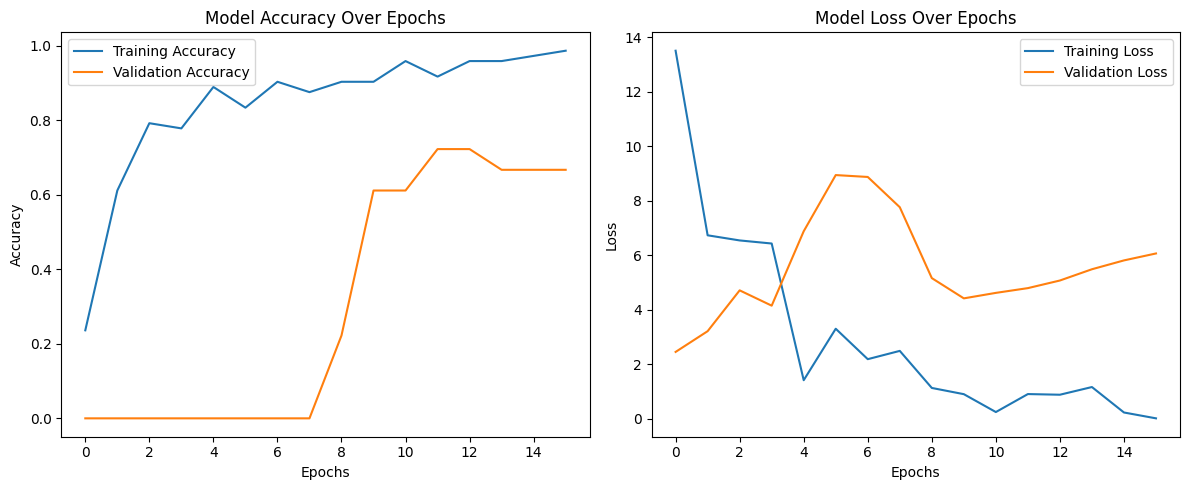

In [15]:
# TRAINING THE MODEL

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Define callbacks for training
training_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# Train the model
training_history = cnn_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=250,
    batch_size=16,
    callbacks=training_callbacks,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(training_history.history['accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [18]:
# Load and preprocess the test dataset
test_dataset_directory = '/content/drive/MyDrive/Artificial Intelligence 6CS012/Week 5/FruitinAmazon/test'

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dataset_directory,
    image_size=(image_height, image_width),
    batch_size=batch_size,
    label_mode='int'
).map(lambda x, y: (normalize_layer(x), y))

# Evaluate the model on the test dataset
evaluation_results = cnn_model.evaluate(test_dataset, verbose=1)

# Unpack the evaluation results
test_loss = evaluation_results[0]  # Loss is the first returned value
test_accuracy = evaluation_results[1]  # Accuracy is the second returned value

# Display evaluation results
print("\n Model Performance on Test Data:")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f" Test Loss: {test_loss:.4f}")


Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step - accuracy: 0.1667 - categorical_xentropy: 1.9177 - loss: 1.9177 - top2_accuracy: 0.4000

 Model Performance on Test Data:
Test Accuracy: 0.1667
 Test Loss: 1.9177


In [21]:
# Save the trained model
cnn_model.save('fclassifier.h5')

# Load the saved model
loaded_model = tf.keras.models.load_model('fclassifier.h5')

# Verify loaded model performance on the test dataset
evaluation_results = loaded_model.evaluate(test_dataset, verbose=1)

# Unpack the evaluation results
loaded_loss = evaluation_results[0]  # Loss is the first returned value
loaded_acc = evaluation_results[1]   # Accuracy is the second returned value

# Display the evaluation results for the loaded model
print(f'Loaded Model Performance on Test Data:')
print(f"Loaded Model Test Accuracy: {loaded_acc:.4f}")
print(f"Loaded Model Test Loss: {loaded_loss:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1667 - categorical_xentropy: 1.9177 - loss: 1.9177 - top2_accuracy: 0.4000
Loaded Model Performance on Test Data:
Loaded Model Test Accuracy: 0.1667
Loaded Model Test Loss: 1.9177


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step

Classification Report:
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.16      0.80      0.27         5
    graviola       0.25      0.20      0.22         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.07      0.17      0.08        30
weighted avg       0.07      0.17      0.08        30



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


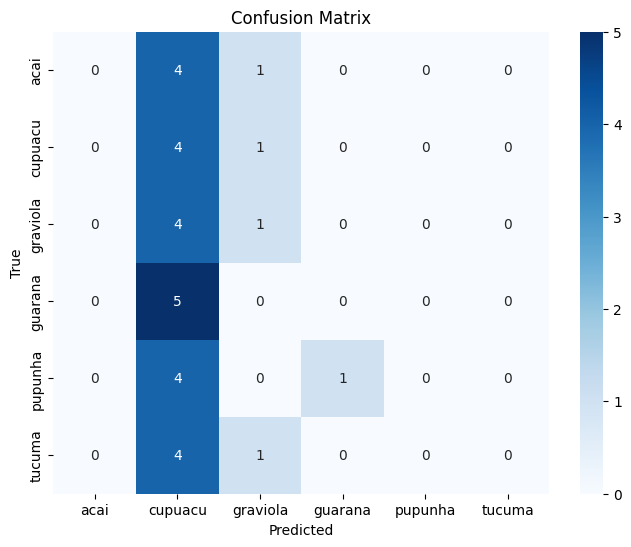

In [24]:
# PREDICTION AND CLASSIFICATION
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Lists to store true labels and predicted labels
y_true = []
y_pred = []

# Iterate through the test dataset to get predictions
for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(loaded_model.predict(images), axis=1))

# Generate classification report
print('\nClassification Report:')
print(classification_report(
    y_true,
    y_pred,
    target_names=class_labels
))

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
